# 01 Data Exploration
EDA: California Property Close Price Prediction

### Set-Up Environment

In [24]:
# %pip install pandas
# %pip install matplotlib
# %pip install seaborn
import pandas as pd
# print("Pandas version:", pd.__version__)
import glob
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import seaborn as sns


# Load and Read Data
Dataset: Recent 6 Months of CRMLSSold files from /raw/California (202512, ... , 202605)

In [25]:
# Find the data files in the data folder and sort by name
data = sorted(glob.glob('../data/CRMLSSold*.csv'))
print(data)

['../data\\CRMLSSold202506.csv', '../data\\CRMLSSold202507.csv', '../data\\CRMLSSold202508.csv', '../data\\CRMLSSold202509.csv', '../data\\CRMLSSold202510.csv', '../data\\CRMLSSold202511.csv', '../data\\CRMLSSold202512.csv', '../data\\CRMLSSold202601.csv', '../data\\CRMLSSold202602.csv', '../data\\CRMLSSold202603.csv', '../data\\CRMLSSold202604.csv', '../data\\CRMLSSold202605.csv', '../data\\CRMLSSold202606.csv']


### Read and filter the CSV files
Mapping requested task-doc variables to existing columns as found in the CRMLSSold*.csv files
- Bedrooms --> BedroomsTotal
- Bathrooms --> BathroomsTotalInteger
- LotSize --> LotSizeAcres

Per task doc, restrict to PropertyType = Residential and PropertySubType = SingleFamilyResidence.

In [26]:
all_csv = []
raw_total = 0

# Apply filters to all files
for file in data:
    #print(f"Processing file: {file}")
    csv = pd.read_csv(file, low_memory=False)
    raw_total += len(csv)

    # restrict analysis per task doc
    csv = csv[(csv['PropertyType'] == 'Residential') & (csv['PropertySubType'] == 'SingleFamilyResidence')].copy()

    all_csv.append(csv)

df = pd.concat(all_csv, ignore_index=True)

# Reverify total files read
print(f'Total files read: {len(all_csv)}')
# Rows before filtering
print(f'Total rows read pre-filter: {raw_total:,}')
print(f'Total rows read post-filter (restrictions): {len(df):,}')

Total files read: 13
Total rows read pre-filter: 283,176
Total rows read post-filter (restrictions): 143,078


## Dataset Overview
Previewing the whole dataset

In [27]:
display(df.head(10))
df.info()
# Summary statistics
df.describe()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
0,TheInlandGateway,TheInlandGateway,NaN,True,NaN,NaN,False,889000.0,523319952,hutton@cbappteam.com,...,NaN,9600.0,0.0,True,2.0,Rim of the World,92352,0.0,9600.0,NaN
1,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,Wood,True,NaN,NaN,False,1899999.0,1118606385,chase.campen@compass.com,...,26x100,10400.0,NaN,False,NaN,NaN,90046,NaN,10400.0,NaN
2,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,NaN,1118606192,stanleylo@greenbanker.com,...,NaN,22505.0,NaN,False,3.0,Other,94010,NaN,22505.0,NaN
3,PacificWest,PacificWest,NaN,True,NaN,NaN,False,865000.0,1118604114,matt@majorleaguesocal.com,...,NaN,4800.0,3.0,False,2.0,Placentia-Yorba Linda Unified,92886,0.0,4800.0,NaN
4,BayEast,BayEast,"Carpet,Laminate",NaN,NaN,NaN,False,875000.0,1118603794,brianrowland.homes@gmail.com,...,NaN,5500.0,NaN,False,4.0,NaN,94546,NaN,5500.0,NaN
5,ContraCosta,ContraCosta,"Vinyl,Wood",NaN,NaN,NaN,False,769645.0,1118602395,ashley@ashleyomalley.com,...,NaN,8050.0,NaN,False,0.0,NaN,94519,NaN,8050.0,NaN
6,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,2375000.0,1118601808,sabine@sabinedillon.com,...,NaN,196891.0,NaN,False,2.0,Sonoma Valley Unified,95476,NaN,196891.0,NaN
7,CitrusValley,CitrusValley,NaN,False,NaN,NaN,False,720000.0,1118601257,letsmegadeal@gmail.com,...,NaN,6576.0,2.0,False,2.0,Chaffey Joint Union High,91764,0.0,6576.0,NaN
8,CitrusValley,CitrusValley,NaN,True,NaN,NaN,False,585000.0,1118600851,letsmegadeal@gmail.com,...,NaN,7405.0,3.0,False,2.0,Alvord Unified,92505,0.0,7405.0,NaN
9,PacificWest,PacificWest,NaN,False,NaN,NaN,False,1775000.0,1118600706,mfierrosjr@gmail.com,...,NaN,4781.0,3.0,False,0.0,Los Angeles Unified,90042,0.0,4781.0,NaN


<class 'pandas.DataFrame'>
RangeIndex: 143078 entries, 0 to 143077
Data columns (total 78 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   BuyerAgentAOR                 138041 non-null  str    
 1   ListAgentAOR                  143045 non-null  str    
 2   Flooring                      92226 non-null   str    
 3   ViewYN                        130030 non-null  object 
 4   WaterfrontYN                  74 non-null      object 
 5   BasementYN                    3464 non-null    object 
 6   PoolPrivateYN                 131892 non-null  object 
 7   OriginalListPrice             142774 non-null  float64
 8   ListingKey                    143078 non-null  int64  
 9   ListAgentEmail                142697 non-null  str    
 10  CloseDate                     143078 non-null  str    
 11  ClosePrice                    143078 non-null  float64
 12  ListAgentFirstName            142120 non-null  str    


,OriginalListPrice,ListingKey,ClosePrice,Latitude,Longitude,LivingArea,ListPrice,DaysOnMarket,FireplacesTotal,AboveGradeFinishedArea,...,ElementarySchoolDistrict,BelowGradeFinishedArea,CoveredSpaces,Stories,LotSizeArea,MainLevelBedrooms,GarageSpaces,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
count,1.427740e+05,1.430780e+05,1.430780e+05,143065.000000,143065.000000,143004.000000,1.430780e+05,143078.000000,0.0,0.0,...,0.0,1021.000000,0.0,128148.000000,1.406420e+05,86970.000000,137448.000000,101374.000000,1.406290e+05,0.0
mean,1.383857e+06,1.134512e+09,1.342062e+06,34.735839,-118.600452,2051.894708,1.269288e+06,39.862900,NaN,NaN,...,NaN,66.991185,NaN,1.352670,2.098009e+04,2.265229,2.007274,107.523592,3.756355e+05,NaN
std,8.063208e+06,1.906691e+07,7.893845e+06,1.768924,3.233273,1049.593977,1.589906e+06,53.140488,NaN,NaN,...,NaN,292.655253,NaN,0.477803,1.128845e+06,1.456901,3.293176,359.199367,1.751203e+07,NaN
min,0.000000e+00,4.217759e+08,0.000000e+00,-22.863239,-124.193201,0.000000,8.000000e+03,-265.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,NaN
25%,6.370000e+05,1.117480e+09,6.250000e+05,33.761153,-119.161909,1388.000000,6.250000e+05,8.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,5.403000e+03,1.000000,2.000000,0.000000,5.663000e+03,NaN
50%,8.990000e+05,1.136709e+09,8.950000e+05,34.084240,-118.031509,1823.000000,8.950000e+05,20.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,7.095000e+03,3.000000,2.000000,0.000000,7.285000e+03,NaN
75%,1.449000e+06,1.151934e+09,1.425000e+06,34.848756,-117.260040,2444.000000,1.399999e+06,52.000000,NaN,NaN,...,NaN,0.000000,NaN,2.000000,9.995000e+03,3.000000,2.000000,132.000000,1.045400e+04,NaN
max,1.302000e+09,1.176283e+09,9.895000e+08,81.000000,120.432670,56500.000000,1.375000e+08,2177.000000,NaN,NaN,...,NaN,3490.000000,NaN,2.000000,4.187423e+08,44.000000,600.000000,23750.000000,1.938943e+09,NaN


## Missing Data
Checking for missing values in the dataframe

            n_rows  n_close_prices  n_close_dates
ListingKey                                       
1137564166       3               2              3
1100754427       2               2              2
1075843364       2               1              2
1101502229       2               1              2
1103248802       2               1              2
1107148790       2               1              2
1107208957       2               1              1
1107335546       2               1              2
1107532363       2               1              2
1108481448       2               1              2
Total duplicated ListingKeys: 99
Total extra rows from duplicates: 100


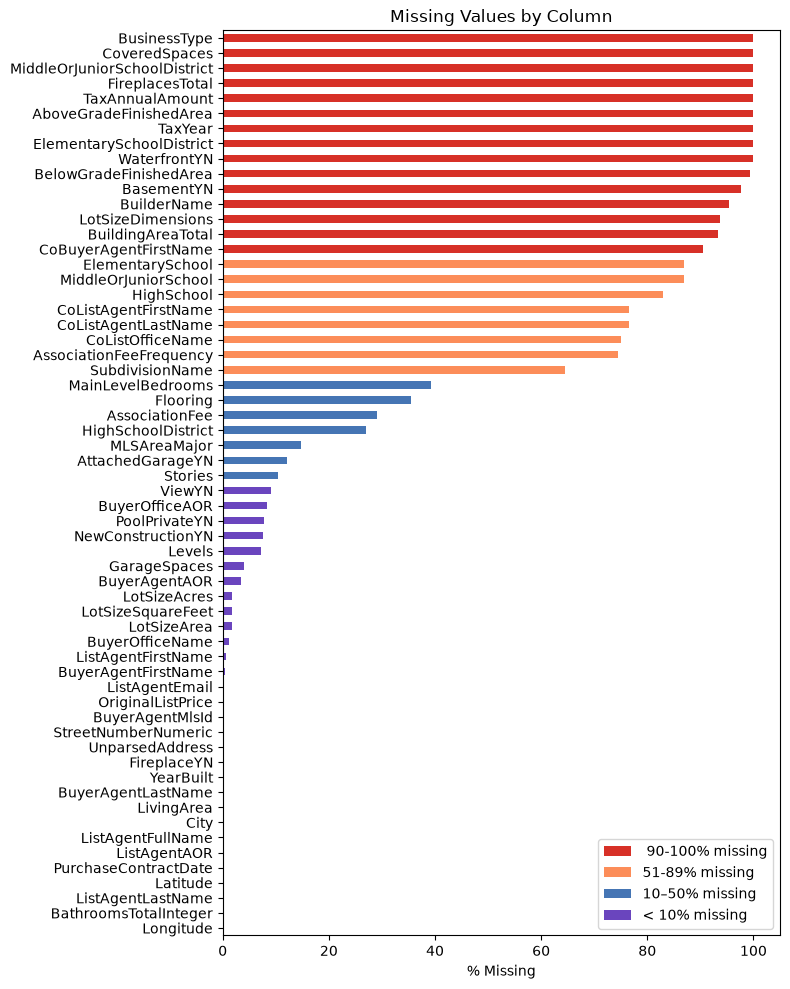

Columns 100% missing (8):
  BusinessType
  CoveredSpaces
  MiddleOrJuniorSchoolDistrict
  FireplacesTotal
  TaxAnnualAmount
  AboveGradeFinishedArea
  TaxYear
  ElementarySchoolDistrict


In [28]:
# Check for duplicates
dupe_keys = df[df['ListingKey'].duplicated(keep=False)]
dupe_summary = (
    dupe_keys.groupby('ListingKey')
    .agg(n_rows=('ListingKey', 'size'),
         n_close_prices=('ClosePrice', 'nunique'),
         n_close_dates=('CloseDate', 'nunique'))
    .sort_values('n_rows', ascending=False)
)
print(dupe_summary.head(10))
# Some ListingKeys appear in two of the six monthly files with the same ClosePrice but different CloseDate, this is likely a listing that was re-reported across month boundaries. 
# To be resolved during preprocessing.

print(f'Total duplicated ListingKeys: {len(dupe_summary)}')
print(f'Total extra rows from duplicates: {(dupe_summary["n_rows"] - 1).sum()}')



# percentage of missing values in each column
missing_pct = (df.isnull().mean() * 100).round(2).sort_values(ascending=False)
missing_nonzero = missing_pct[missing_pct > 0]

colors = missing_nonzero.map(
    lambda x: '#d73027' if x >= 90 else '#fc8d59' if x > 50 else '#4575b4' if x > 10 else "#6a45be")

# Visualize missing values
plt.figure(figsize=(8, 10))
missing_nonzero.plot(kind='barh', color=colors)
plt.xlabel('% Missing')
plt.title('Missing Values by Column')
plt.gca().invert_yaxis()

legend_elements = [ 
    Patch(facecolor='#d73027', label=' 90-100% missing'),
    Patch(facecolor='#fc8d59', label='51-89% missing'),
    Patch(facecolor='#4575b4', label='10–50% missing'),
    Patch(facecolor='#6a45be', label='< 10% missing'),
]

plt.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

# Display columns completely missing (100%)
full_null = missing_pct[missing_pct == 100]
print(f'Columns 100% missing ({len(full_null)}):')
for col in full_null.index:
    print(f'  {col}')

## Focused Variables

Per task doc, exploring distributions of:
- ClosePrice (target variable)
- LivingArea
- Bedrooms → BedroomsTotal
- Bathrooms → BathroomsTotalInteger
- LotSize → LotSizeAcres

In [29]:
key_vars = ['ClosePrice', 'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeAcres']
key_df = df[key_vars].copy()

# Get outliers of the key variables
print(display(key_df.describe(percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])))

# Re-check for missing values in the key variables
print(f' Missing values in key_df:\n{key_df.isnull().sum()}')

,ClosePrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeAcres
count,1.430780e+05,143004.000000,143078.000000,143066.000000,140628.000000
mean,1.342062e+06,2051.894708,3.496338,2.636664,14.087051
std,7.893845e+06,1049.593977,0.962588,1.130120,783.606002
min,0.000000e+00,0.000000,0.000000,0.000000,0.000000
1%,2.350000e+05,740.000000,2.000000,1.000000,0.040000
5%,3.660000e+05,968.000000,2.000000,1.000000,0.073900
10%,4.425000e+05,1104.000000,2.000000,2.000000,0.097600
25%,6.250000e+05,1388.000000,3.000000,2.000000,0.130000
50%,8.950000e+05,1823.000000,3.000000,2.000000,0.167300
75%,1.425000e+06,2444.000000,4.000000,3.000000,0.240000


None
 Missing values in key_df:
ClosePrice                  0
LivingArea                 74
BedroomsTotal               0
BathroomsTotalInteger      12
LotSizeAcres             2450
dtype: int64


In [30]:
# Extra checks into the key variables

# Investigating LivingArea == 0
print(f' Number of zero values in LivingArea: {(key_df["LivingArea"] == 0).sum()}')

# Investigating BedroomsTotal == 0
print(f' Number of zero values in BedroomsTotal: {(key_df["BedroomsTotal"] == 0).sum()}')

# Investigating BathroomsTotalInteger == 0
print(f' Number of zero values in BathroomsTotalInteger: {(key_df["BathroomsTotalInteger"] == 0).sum()}')

# Investigating LotSizeAcres == 0
print(f' Number of zero values in LotSizeAcres: {(key_df["LotSizeAcres"] == 0).sum()}')
print(f' Top 10 largest LotSizeAcres values: {key_df["LotSizeAcres"].sort_values(ascending=False).head(10).tolist()}')

 Number of zero values in LivingArea: 53
 Number of zero values in BedroomsTotal: 77
 Number of zero values in BathroomsTotalInteger: 61
 Number of zero values in LotSizeAcres: 350
 Top 10 largest LotSizeAcres values: [127631.0, 94090.0, 88862.0, 87991.0, 68393.0, 63598.0, 60113.0, 60112.0, 59241.0, 58302.0]


### Analysis of Outliers and Missingness Findings on Focused Variables:
- ClosePrice: 
    - No missing values across the dataframe of the recent 6 months (6,172,700 total values).
    - Average ClosePrice = $1,340,106.00 across all properties in the dataframe.
    - Lowest ClosePrice value for a property input into the dataframe = $1.75. This is an unrealistic price of a property and will need to be investigated.
    - Largest ClosePrice value is $796,000,000.00, an extreme difference in comparison to the 99th percentile of $6,500,000.00. This outlier will also need to be investigated to determine potential error.
    - According to the outliers we can expect the collective data of ClosePrice to be strongly right skewed due to the outlier.
    
- LivingArea:
    - 30 missing value across the dataframe of the revent 6 months (6,172,670 total values).
    - Average of 2055.55 total units of livable area in a property listed in the dataframe
    - The minimum value of livable area is 0.00, found in 19 rows. As the value signify livable-ness in units, this warrants deeper look as to how the property was assessed to be not livable at all.
    - The largest LivingArea is 23,314 units. Against the 99th percentile of 5,698 units, there will be a right skew of the data.
    - Notably, it will be important to ensure consistency in units used across this data to ensure correctness. The .csv is missing "LivingAreaUnits" as a variable. 

- BedroomsTotal:
    - No missing values across the dataframe of the recent 6 months (6,172,700 total values).
    - Average BedroomsTotal = 3.45, meaning most properties in the data frame have 3-4 bedrooms.
    - Lowest amount of Bedrooms is 0.00, found in 29 rows. For a single family residence, this value doesn't make sense and will need to be re-assessed.
    - The maximum amount of Bedrooms in a property as entered in the data is 22. This could be a value to investigate since the 99th percentile ends around 6 Bedrooms of the properties.There will be a right skew of the data visualization. The property as a whole will need to be checked as it may be structurally different.
- BathroomsTotalInteger:
    - 1 missing value across the dataframe of the recent 6 months (6,172,699 total values).
    - Average BathroomsTotalInteger = 2.64, meaning most properties in the data frame have 2-3 bathrooms.
    - Lowest amount of Bathrooms is 0.00, found in 24 rows. For a single family residence, this value doesn't make sense and will need to be re-assessed.
    - The maximum amount of Bathrooms in a property as entered in the data is 22. This could be a value to investigate since the 99th percentile ends around 6 Bathrooms of the properties.There will be a right skew of the data visualization. The property as a whole will need to be checked as it may be structurally different.

** As BedroomsTotal and BathroomsTotalInteger share a maximum outlier of 22, it is worth investigating potential correlation.**

- LotSizeAcres:
    - 1083 missing values across the dataframe of the recent 6 months (6,171,617 total values). These entries will need to be flagged and checked for issues. A potential reason could be due to inconsistency in unit that causes LotSizeAcres to appear as null.
    - Average LotSizeAcres = 10.82, meaning most properties in the data frame are about 10-11 acres.
    - Lowest amount of Bathrooms is 0.00, found in 185 rows. For any property to have a size of 0, is unrealistic. These entries will need to be flagged and checked for issues. A potential issue could be due to inconsistency in unit that causes LotSizeAcres to appear as 0.
    - The maximum acreage of the LotSize is 60,113 acres. Compared to the 99th percentile of 7.06 acres, it's clear that the outlier has caused an extreme right skew in the distribution where the mean exceeds the 99th percentile.
    - Looking into the largest values entered under LotSizeAcres, 43560.0 appears twice, which if it is meant to be square feet instead of acre, would equal exactly 1 acre. There is a high potential of inconsistency in the values and units entered for Lot size. We can check plausibility of the especially larger acreage values by cross-checking with the physical location of the properties. 

# Explore Distributions
Exploring the 7 variables as previously defined in key_vars.
- ClosePrice (Target Variable)
- LivingArea
- Bedrooms → BedroomsTotal
- Bathrooms → BathroomsTotalInteger
- LotSize → LotSizeAcres

## ClosePrice (Target Variable)
The amount of money paid by the purchaser to the seller for the property under the agreement
From previous, outliers and percentiles assessment, the distribution will be right skewed.

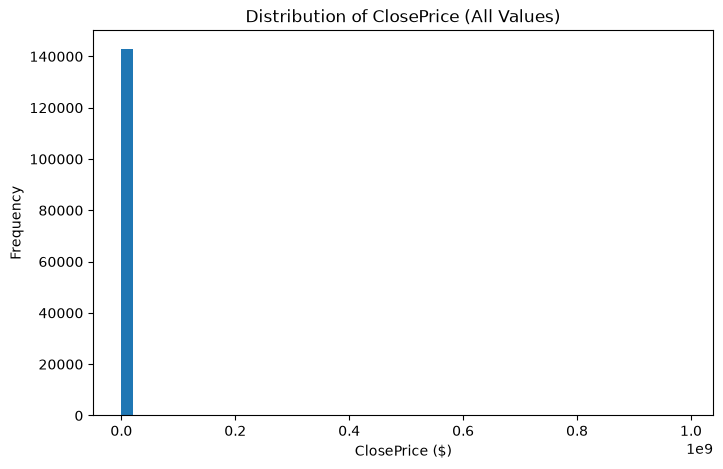

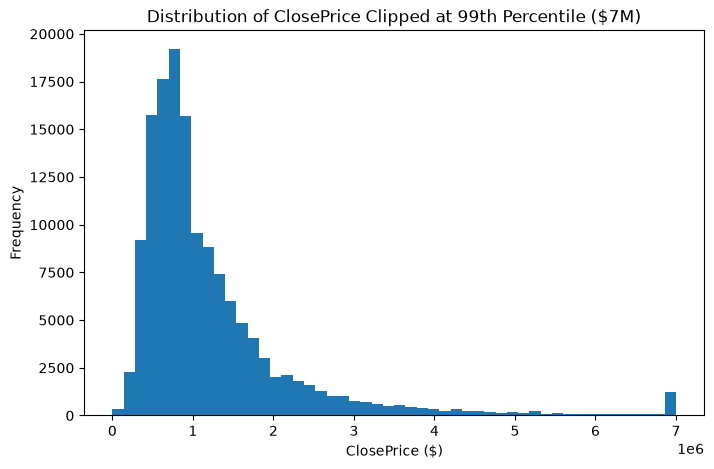

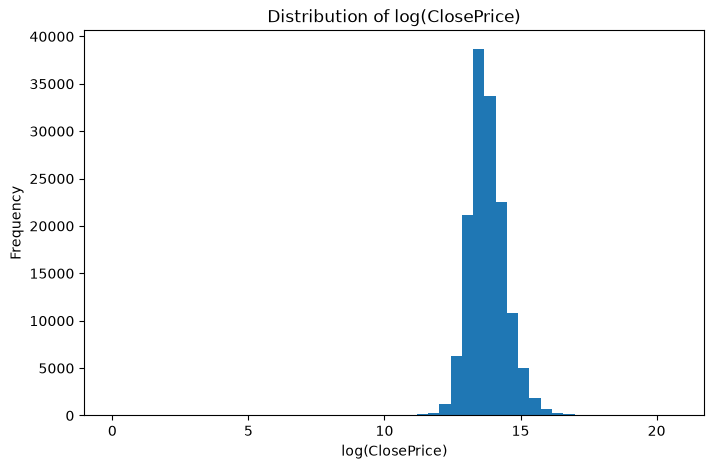

In [31]:
# Full Distribution of ClosePrice values
plt.figure(figsize=(8, 5))
plt.hist(key_df["ClosePrice"], bins=50)
plt.title("Distribution of ClosePrice (All Values)")
plt.xlabel("ClosePrice ($)")
plt.ylabel("Frequency")
plt.show()

# Zoomed in on ClosePrice values clipped to the 99th percentile $6-7M for better visualization of the distribution
plt.figure(figsize=(8, 5))
plt.hist(np.clip(key_df["ClosePrice"], key_df["ClosePrice"].min(), 7_000_000), bins=50)
plt.title("Distribution of ClosePrice Clipped at 99th Percentile ($7M)")
plt.xlabel("ClosePrice ($)")
plt.ylabel("Frequency")
plt.show()

# Log-scale distribution
plt.figure(figsize=(8, 5))
plt.hist(np.log1p(key_df["ClosePrice"]), bins=50)
plt.title("Distribution of log(ClosePrice)")
plt.xlabel("log(ClosePrice)")
plt.ylabel("Frequency")
plt.show()



### Interpretation

According to the original scale and the clipped scale distributions of ClosePrice, there is a clear right-skew driven by the extreme outlier as previously determined. The clipped distribution offers a closer look at the majority of the data, showing a clearer concentration estimated between $400K and $1.5M. The log-transformed version is more visually symmetric which allows for the reframing of differences in relative versus absolute terminology. The concentration within the log-scaled distribution is roughly between 13.0 and 15.0 which convert to $440K to $3.3M

## LivingArea
The total livable area within the structure.
Unit of this variable is not defined across the dataframe, posing potential issues to be investigated in week 3.

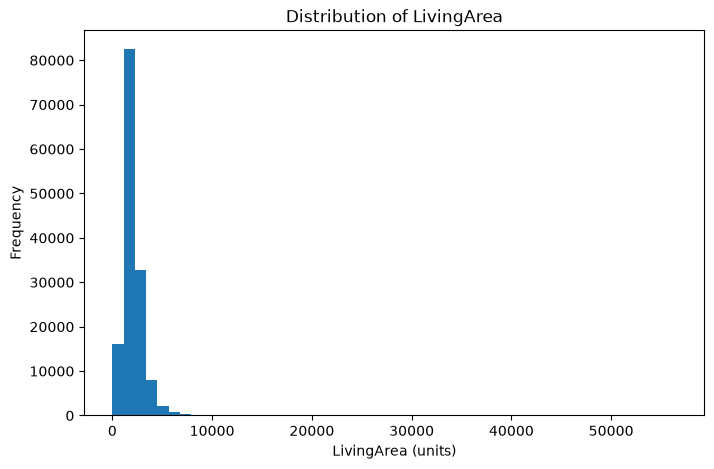

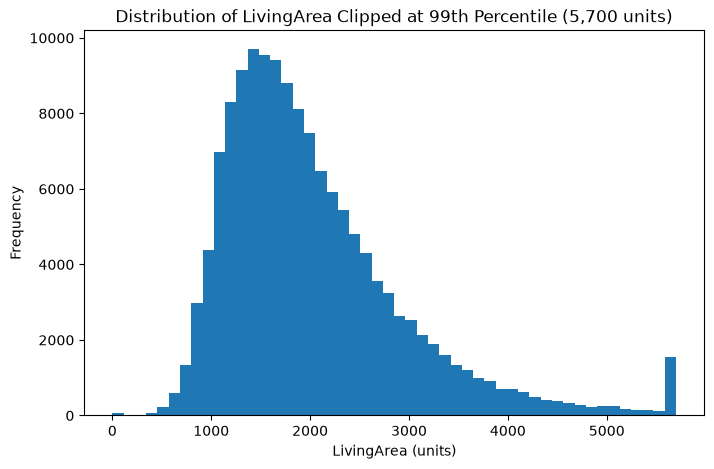

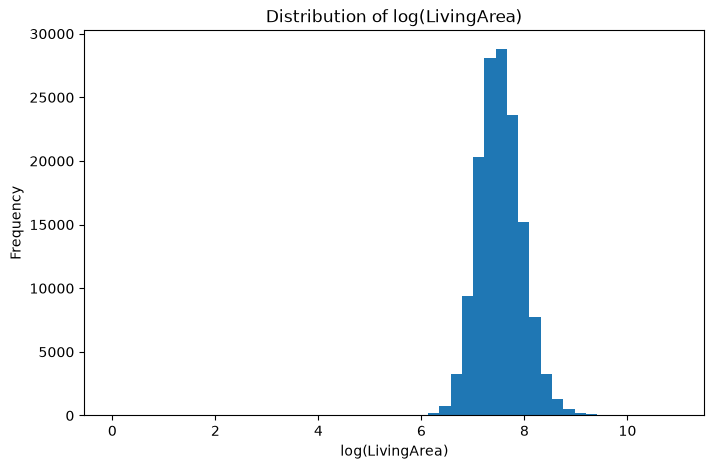

In [32]:
# Full Distribution of LivingArea values
plt.figure(figsize=(8, 5))
plt.hist(df["LivingArea"], bins=50)
plt.title("Distribution of LivingArea")
plt.xlabel("LivingArea (units)")
plt.ylabel("Frequency")
plt.show()

# Zoomed in on LivingArea values clipped to the 99th percentile 5,700 for better visualization of the distribution
plt.figure(figsize=(8, 5))
plt.hist(np.clip(key_df['LivingArea'], key_df['LivingArea'].min(), 5_700), bins=50)
plt.title('Distribution of LivingArea Clipped at 99th Percentile (5,700 units)')
plt.xlabel('LivingArea (units)')
plt.ylabel('Frequency')
plt.show()

# Log-scale distribution of LivingArea
plt.figure(figsize=(8, 5))
plt.hist(np.log1p(key_df['LivingArea']), bins=50)
plt.title('Distribution of log(LivingArea)')
plt.xlabel('log(LivingArea)')
plt.ylabel('Frequency')
plt.show()

### Interpretation

According to the original scale and the clipped scale distributions of LivingArea, there is a clear right-skew driven by the extreme outlier as previously determined. The clipped distribution offers a closer look at the majority of the data, showing a clearer concentration estimated between 1000 and 2500 units of Living area. The log-transformed version is more visually symmetric which allows for the reframing of differences in relative versus absolute terminology. The concentration within the log-scaled distribution is roughly between 7.0 and 8.0 which after conversion align with the previously determined median of the distribution.

## Bedrooms (= BedroomsTotal)
The total number of bedrooms in the property.
The values of this variable are expected to be whole integers.

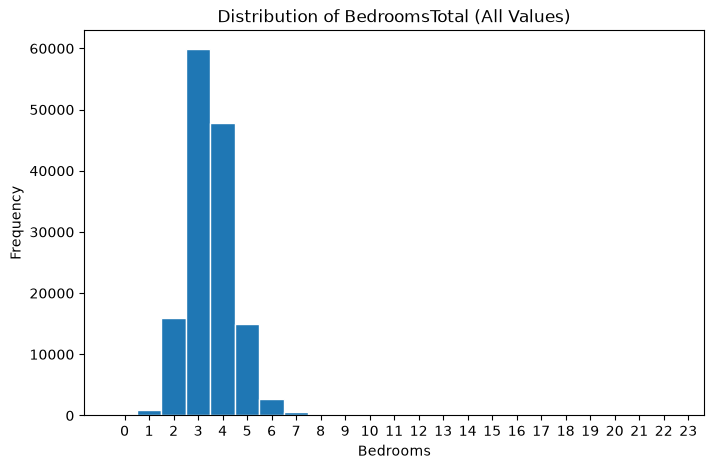

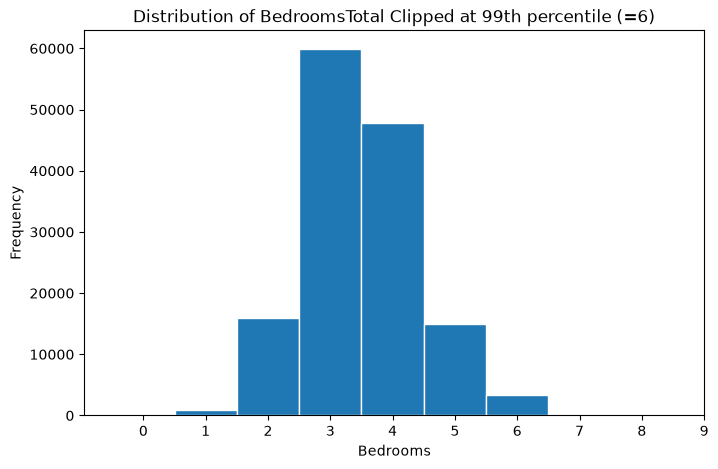

In [33]:
# Full Distribution of BedroomsTotal values
plt.figure(figsize=(8, 5))
plt.hist(key_df['BedroomsTotal'].dropna(), bins=range(0, 24), align='left', edgecolor='white')
plt.title('Distribution of BedroomsTotal (All Values)')
plt.xlabel('Bedrooms')
plt.ylabel('Frequency')
plt.xticks(range(0, 24))
plt.show()

# Zoomed in on BedroomsTotal values clipped to the 99th percentile 6 for better visualization of the distribution
plt.figure(figsize=(8, 5))
plt.hist(np.clip(key_df['BedroomsTotal'].dropna(), 0, 6), bins=range(0, 10), align='left', edgecolor='white')
plt.title('Distribution of BedroomsTotal Clipped at 99th percentile (=6)')
plt.xlabel('Bedrooms')
plt.ylabel('Frequency')
plt.xticks(range(0, 10))
plt.show()

### Interpretation

Bedrooms (BedroomsTotal) takes integer values with less extreme of a right skew due to the outlier of 22 bedrooms. The distributions show that most properties in the dataframe have 3-4 bedrooms total.

## Bathrooms (= BathroomsTotalInteger)
The total number of Bathrooms in the property.
The values of this variable are expected to be whole integers.

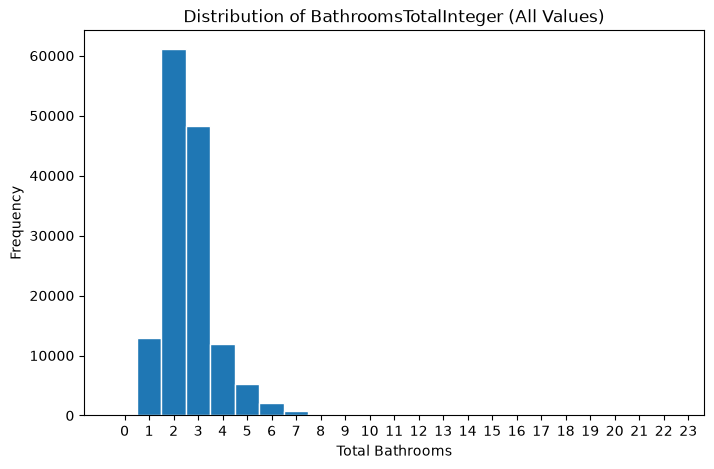

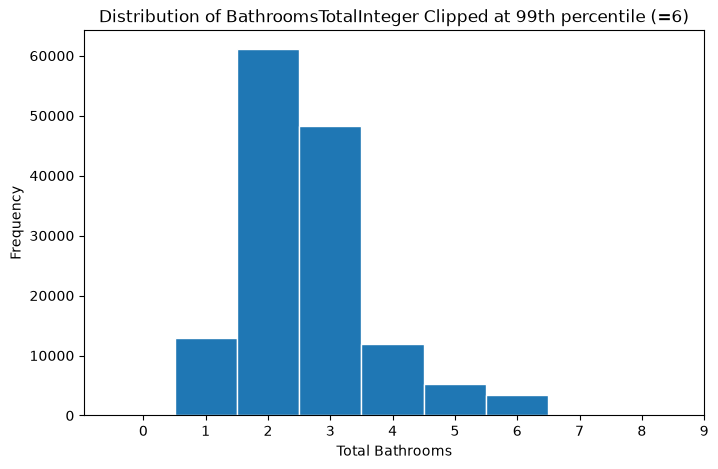

In [34]:
# Full Distribution of BathroomsTotalInteger values
plt.figure(figsize=(8, 5))
plt.hist(key_df['BathroomsTotalInteger'].dropna(), bins=range(0, 24), align='left', edgecolor='white')
plt.title('Distribution of BathroomsTotalInteger (All Values)')
plt.xlabel('Total Bathrooms')
plt.ylabel('Frequency')
plt.xticks(range(0, 24))
plt.show()

# Zoomed in on BathroomsTotalInteger values clipped to the 99th percentile 6 for better visualization of the distribution
plt.figure(figsize=(8, 5))
plt.hist(np.clip(key_df['BathroomsTotalInteger'].dropna(), 0, 6), bins=range(0, 10), align='left', edgecolor='white')
plt.title('Distribution of BathroomsTotalInteger Clipped at 99th percentile (=6)')
plt.xlabel('Total Bathrooms')
plt.ylabel('Frequency')
plt.xticks(range(0, 10))
plt.show()



### Interpretation

Total Bathrooms (BathroomsTotalInteger) takes integer values with less extreme of a right skew due to the outlier of 22 bathrooms. The distributions show that most properties in the dataframe have 2-3 bathrooms total.

### TEST: Checking potential overlaps between BedroomsTotal and BathroomsTotalInteger

Reason: Both variables of the dataframe share a specific maximum value of 22

In [35]:
print(display(key_df[(key_df['BedroomsTotal'] == 22) & (key_df['BathroomsTotalInteger'] == 22)]))
print(display(key_df[key_df['BedroomsTotal'] == 22]))
print(display(key_df[key_df['BathroomsTotalInteger'] == 22]))

,ClosePrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeAcres


None


,ClosePrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeAcres
80375,1200000.0,5814.0,22.0,18.0,0.1839


None


,ClosePrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeAcres
130218,21500000.0,23314.0,10.0,22.0,21.48


None


### Analysis

There are no results proving that the maximum of 22 bedrooms property is the same as the property with 22 bathrooms.

## LotSize (= LotSizeAcres)
The total Acres of the lot.
Previously flagged potential errors in unit conversion/consistency of units used.

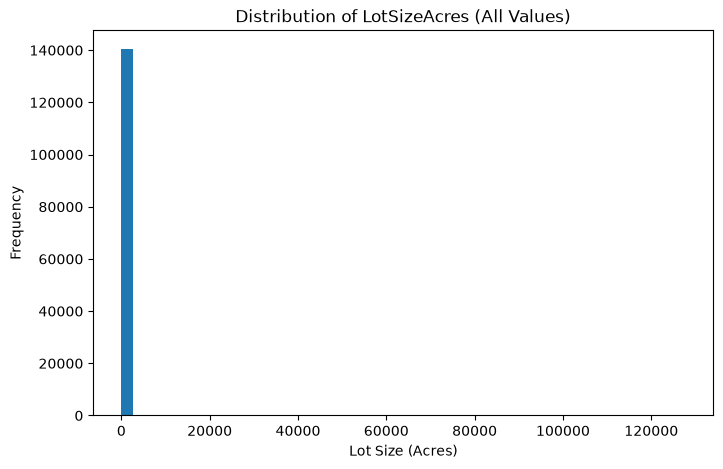

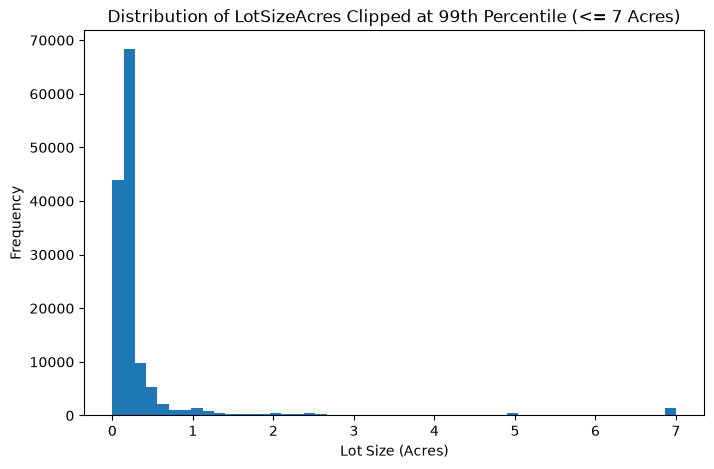

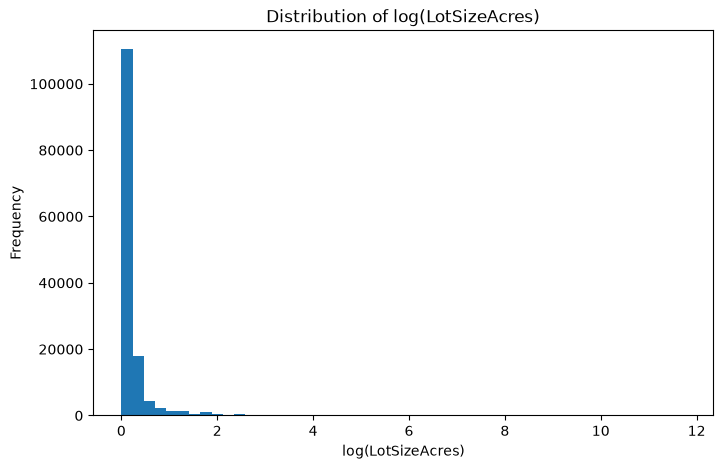

In [36]:
# Full Distribution of LotSizeAcres values
plt.figure(figsize=(8, 5))
plt.hist(key_df["LotSizeAcres"], bins=50)
plt.title("Distribution of LotSizeAcres (All Values)")
plt.xlabel("Lot Size (Acres)")
plt.ylabel("Frequency")
plt.show()

# Zoomed in on LotSizeAcres clipped at 99th percentile (<= 7 Acres) for better visualization of the distribution
plt.figure(figsize=(8, 5))
plt.hist(np.clip(key_df["LotSizeAcres"], 0, 7), bins=50)
plt.title("Distribution of LotSizeAcres Clipped at 99th Percentile (<= 7 Acres)")
plt.xlabel("Lot Size (Acres)")
plt.ylabel("Frequency")
plt.show()

# log-scale distribution of LotSizeAcres
plt.figure(figsize=(8, 5))
plt.hist(np.log1p(key_df['LotSizeAcres']), bins=50)
plt.title('Distribution of log(LotSizeAcres)')
plt.xlabel('log(LotSizeAcres)')
plt.ylabel('Frequency')
plt.show()

### Interpretation
According to the original scale and the clipped scale distributions of Lot Size (LotSizeAcres), there is a clear extreme right-skew driven by the extreme outlier as previously determined. The clipped distribution offers a bit of a closer look at the majority of the data, showing a clearer concentration estimated between 0 and less than 0.5 Acres. The log-transformed version is interesting because it doesn't offer a symmetrical visualization as the other variables did, signalling a larger issue that will require more preprocessing in week 3.

## Relationships with ClosePrice Scatter Plots

In this section, I will compare the key variables as defined in the task doc against the ClosePrice variable and follow with added variables from the original dataframe for a larger picture.

- A. Each Key_Var against ClosePrice
- B. Other potentially price impacted variables against ClosePrice

### A. Each Key_Var against ClosePrice

In this section I will compare the other key variables (LivingArea, BedroomsTotal, BathroomsTotalInteger, LotSizeAcres) each against ClosePrice. Per the skews previously analyzed, the variables will be clipped to their 99th percentile for clearer results.

- LivingArea and LotSizeAcres are continuous variables that will be best represented through scatterplots.
- BedroomsTotal and BathroomsTotalIntegers are discrete variables which will be best represented through boxplots.

In [37]:
# Clipped view for relationship analysis (1st-99th percentile)

plot_df = key_df.copy()
for col in ['ClosePrice', 'LivingArea', 'LotSizeAcres']:
    low, high = plot_df[col].quantile([0.01, 0.99])
    plot_df = plot_df[plot_df[col].between(low, high)]

#Check to ensure clipping:
print(f'Rows in clipped view: {len(plot_df):,} (from {len(key_df):,})')

Rows in clipped view: 132,338 (from 143,078)


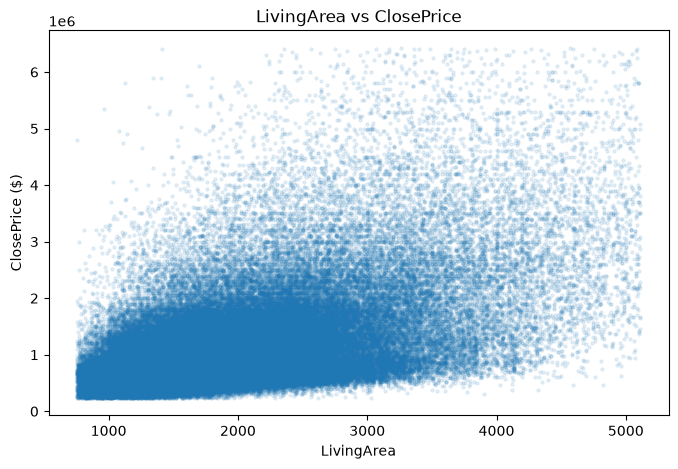

In [38]:
# LivingArea vs ClosePrice scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(plot_df['LivingArea'], plot_df['ClosePrice'], alpha=0.1, s=5)
plt.title('LivingArea vs ClosePrice')
plt.xlabel('LivingArea')
plt.ylabel('ClosePrice ($)')
plt.show()

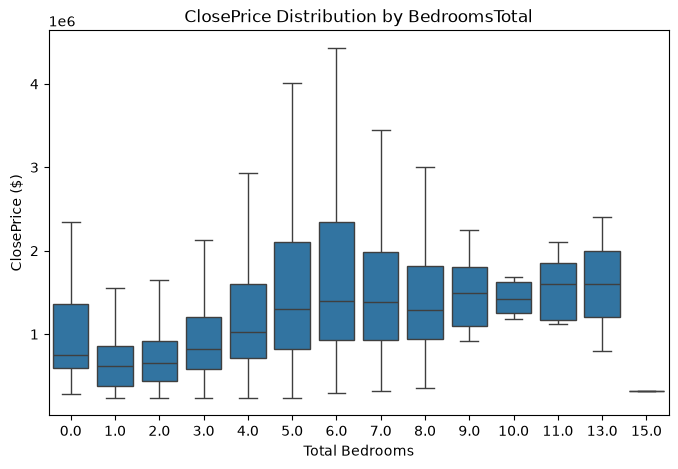

In [39]:
# Bedrooms vs ClosePrice box plot

plt.figure(figsize=(8, 5))
sns.boxplot(data=plot_df, x='BedroomsTotal', y='ClosePrice', showfliers=False)
plt.title('ClosePrice Distribution by BedroomsTotal')
plt.xlabel('Total Bedrooms')
plt.ylabel('ClosePrice ($)')
plt.show()

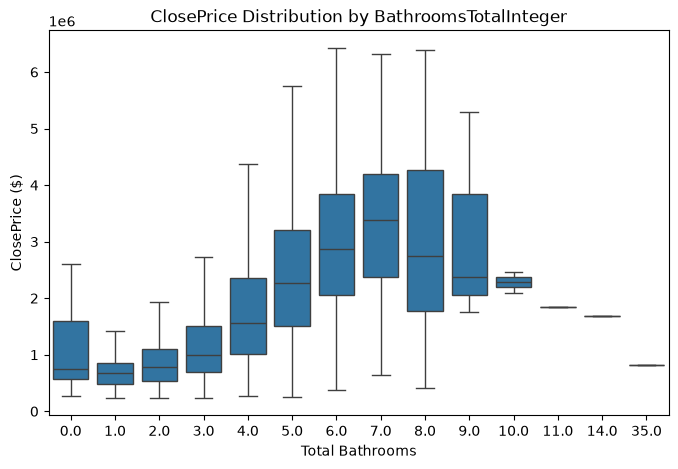

In [40]:
# Bathrooms vs ClosePrice box plot

plt.figure(figsize=(8, 5))
sns.boxplot(data=plot_df, x='BathroomsTotalInteger', y='ClosePrice', showfliers=False)
plt.title('ClosePrice Distribution by BathroomsTotalInteger')
plt.xlabel('Total Bathrooms')
plt.ylabel('ClosePrice ($)')
plt.show()

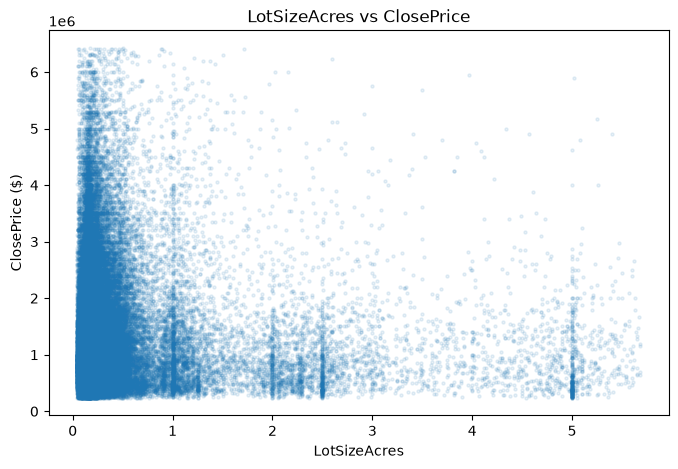

In [41]:
# LostSizeAcres vs ClosePrice scatter plot

plt.figure(figsize=(8, 5))
plt.scatter(plot_df['LotSizeAcres'], plot_df['ClosePrice'], alpha=0.1, s=5)
plt.title('LotSizeAcres vs ClosePrice')
plt.xlabel('LotSizeAcres')
plt.ylabel('ClosePrice ($)')
plt.show()

### Part A Interpretation

* LivingArea vs ClosePrice:
    - The scatterplot here shows a concentration between the 500 to 2500 LivingArea up to $1.5 Million in ClosePrice. In other words, we could say that the scatterplot implies that properties with a LivingArea of about 1000 units have a ClosePrice of up to $1 Million
    - There's a clear positive association between the two variables here. 
* Bedrooms
    - The box plot shows a positive relationship where the median closing prices. There is a reasonable implication that properties with a higher closing price are more likely to have more bedrooms. There are still variation through the number of bedrooms, for example the dip at 8 bedrooms despite expecting higher closing prices seems to imply other additional factors are disrupting the general concept.
* Bathrooms
    - The box plot is a more clear postive relationship demonstrating that properties with more total bathrooms are expected to have higher closing prices.
    - The clear trend indicates that BathroomTotalInteger is a more stable standalone predictor for ClosePrice.
* LotSizeAcres vs ClosePrice:
    - The scatterplot here shows a concentration between 0 up to 1 acre of a lot size with ClosePrice up to $3-4 Million. The visual implies that properties with a lot size of up to half and acre usually had a ClosePrice up to $2 Million.
    - There exists an interesting association that makes it appear that smaller lot sizes can have the highest close prices. This leads into the need to consider the imporant factor of physical location of the property that drives different pricing on the acreage.

Based on these relationships, for ClosePrice, LivingArea and BathroomTotalInteger are the strongest predictors, with LotSizeAcres being the weakest standalone against ClosePrice.

### B. Other potentially price impacted variables against ClosePrice

In this section I will compare for relationships with ClosePrice with variables from the original dataframe, such as YearBuilt, Location (CountyorParish), Boolean Variables (such as ammentity types), and standouts from the missingness results.

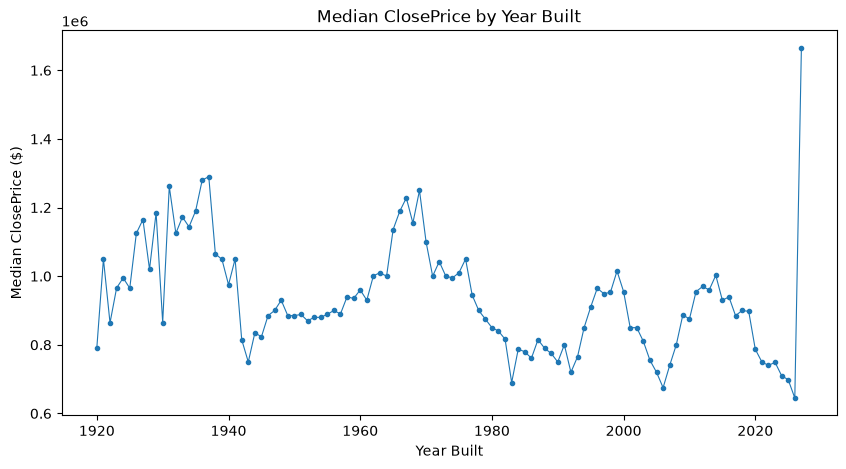

In [42]:
# YearBuilt vs ClosePrice
year_df = df[['YearBuilt', 'ClosePrice']].copy()
reliable = year_df[year_df['YearBuilt'] >= 1920]
median_by_year = reliable.groupby('YearBuilt')['ClosePrice'].median()

plt.figure(figsize=(10, 5))
median_by_year.plot(marker='.', linewidth=0.8)
plt.title('Median ClosePrice by Year Built')
plt.xlabel('Year Built')
plt.ylabel('Median ClosePrice ($)')
plt.show()

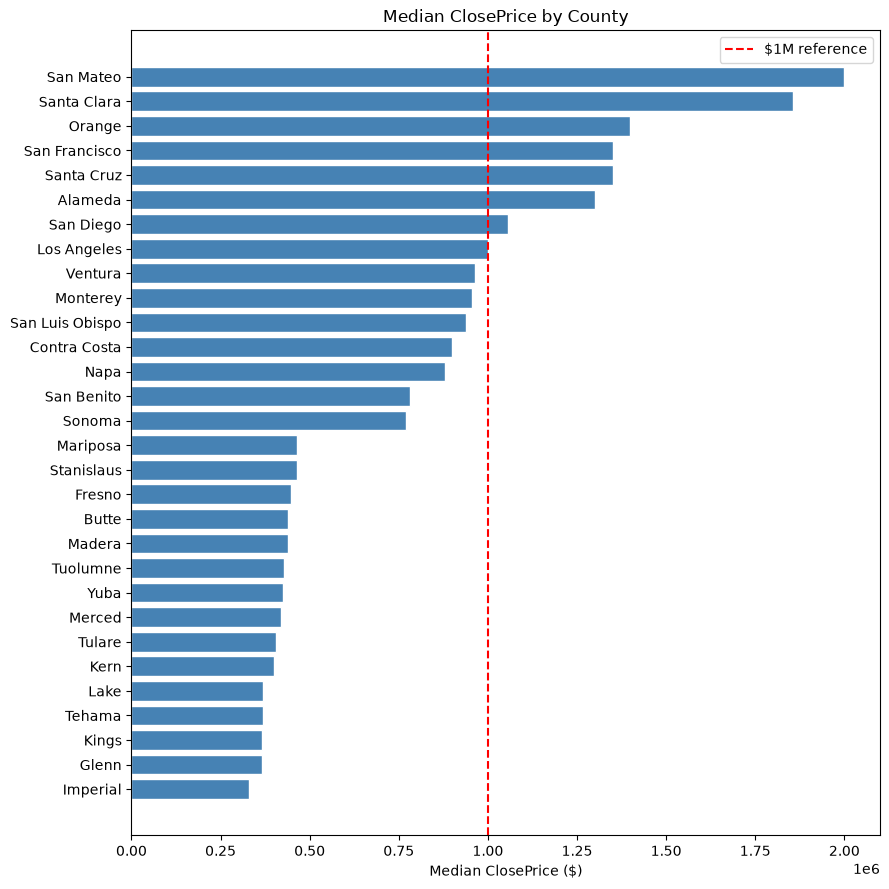

,n_sales,median_price
CountyOrParish,,
San Mateo,1949,2000000.0
Santa Clara,4054,1855000.0
Orange,13429,1400000.0
San Francisco,225,1350000.0
Santa Cruz,952,1350000.0
Alameda,6830,1300000.0
San Diego,15561,1055000.0
Los Angeles,34914,1000000.0
Ventura,4741,965000.0


In [43]:
# CountyorParish vs ClosePrice

county_df = df[['CountyOrParish', 'ClosePrice']].copy()

# Filter ClosePrice to 1st-99th percentile
low, high = county_df['ClosePrice'].quantile([0.01, 0.99])
county_df = county_df[county_df['ClosePrice'].between(low, high)]

# Median price by county, requiring at least 50 sales for a reliable median
county_stats = (
    county_df.groupby('CountyOrParish')['ClosePrice']
    .agg(n_sales='size', median_price='median')
    .query('n_sales >= 50')
    .sort_values('median_price', ascending=False)
)

# Plot top 15 and bottom 15 for a high-vs-low comparison
top_bottom = pd.concat([county_stats.head(15), county_stats.tail(15)])

plt.figure(figsize=(9, 9))
plt.barh(top_bottom.index, top_bottom['median_price'], color='steelblue', edgecolor='white')
plt.gca().invert_yaxis()
plt.axvline(1_000_000, color='red', linestyle='--', linewidth=1.5, label='$1M reference')
plt.title('Median ClosePrice by County')
plt.xlabel('Median ClosePrice ($)')
plt.legend()
plt.tight_layout()
plt.show()

display(county_stats)

WaterfrontYN
NaN     143004
True        74
Name: count, dtype: int64
Non-null WaterfrontYN rows: 74 (0.05% of data)
               n     median
WaterfrontYN               
True          74  1715000.0


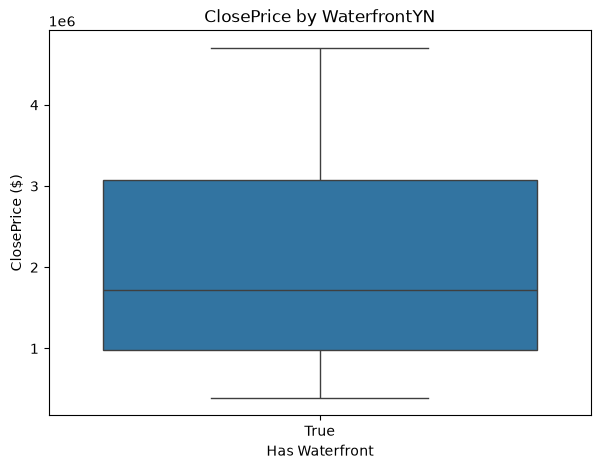

In [44]:
# Boolean & Missing Value: WaterFrontYN vs ClosePrice 
# This variable indicates whether the property is a waterfront or not. 
# In this dataframe, it is almost 100% missing across the data for the last 6 months. 

waterfront_df = df[['WaterfrontYN', 'ClosePrice']].dropna(subset=['WaterfrontYN'])  

print(df['WaterfrontYN'].value_counts(dropna=False))
print(f"Non-null WaterfrontYN rows: {df['WaterfrontYN'].notna().sum()} "
      f"({df['WaterfrontYN'].notna().mean()*100:.2f}% of data)")

print(waterfront_df.groupby('WaterfrontYN')['ClosePrice'].agg(n='size', median='median'))

# Boxplot
plt.figure(figsize=(7, 5))
sns.boxplot(data=waterfront_df, x='WaterfrontYN', y='ClosePrice', showfliers=False)
plt.title('ClosePrice by WaterfrontYN')
plt.xlabel('Has Waterfront')
plt.ylabel('ClosePrice ($)')
plt.show()


AttachedGarageYN
True     105096
False     20683
NaN       17299
Name: count, dtype: int64
Non-null AttachedGarageYN rows: 125779 (87.91% of data)
                       n    median
AttachedGarageYN                  
False              20022  888000.0
True              103243  891000.0


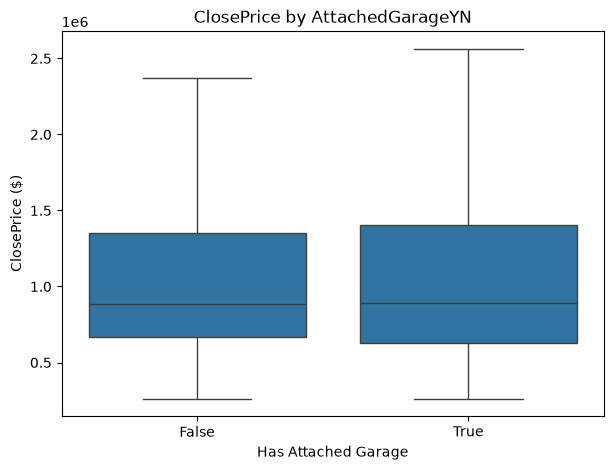

In [45]:
# Boolean: AttachedGarageYN vs ClosePrice

garage_df = df[['AttachedGarageYN', 'ClosePrice']].dropna(subset=['AttachedGarageYN'])

low, high = garage_df['ClosePrice'].quantile([0.01, 0.99])
garage_df = garage_df[garage_df['ClosePrice'].between(low, high)]

print(df['AttachedGarageYN'].value_counts(dropna=False))
print(f"Non-null AttachedGarageYN rows: {df['AttachedGarageYN'].notna().sum()} "
      f"({df['AttachedGarageYN'].notna().mean()*100:.2f}% of data)")

print(garage_df.groupby('AttachedGarageYN')['ClosePrice'].agg(n='size', median='median'))

# Boxplot
plt.figure(figsize=(7, 5))
sns.boxplot(data=garage_df, x='AttachedGarageYN', y='ClosePrice', showfliers=False)
plt.title('ClosePrice by AttachedGarageYN')
plt.xlabel('Has Attached Garage')
plt.ylabel('ClosePrice ($)')
plt.show()

### Part B Interpretation

* YearBuilt vs ClosePrice

The figure reveals a general downward trend in median closing prices, where the newer homes built closer to the present are generally closing for much lwoer values, under $1 Million. In comparison, homes back in the 1930s - 40s and 70s had over $1 Million in closing prices. It's necessary to note that the values earlier in the timeline may not even be adjusted for inflation but in this case, the pulled recent 6 months are expected to have consistency in the dollar values.

* CountyorParish vs ClosePrice

The top 3 most expensive locations were all part of the Bay Area of California, where the regions could be considered busy areas. The least expensive counties were all located in the more northern region of California where they are compromised of smaller towns.

* WaterFront vs ClosePrice 

WaterfrontYN is unusable for relationship analysis. The dataframe has 36 rows (0.06% of the dataframe), which are all marked as True with no False values at all, so 
there is no comparison group to measure a price difference against. These limited data entries make WaterFront and other variables with near 100% missingness unable to be assessed.

* AttachedGarageYN

This was a follow up test of another boolean variable except this time, as there was more existing data entries compared to WaterFrontYN, the visual offers a more substantial connection to ClosePrice, with many entries under both True and False. As such this makes the variable more testable but actually seeing the visualization, this particular variable just doesn't have much of a significant relationship to ClosePrice according the the box plots.

## Correlation Across the Variables

Rows used for correlation: 129,243
Spearman correlation with ClosePrice: 
LivingArea               0.473817
BathroomsTotalInteger    0.428559
BedroomsTotal            0.323055
LotSizeAcres             0.073206
YearBuilt               -0.136808
Name: ClosePrice, dtype: float64


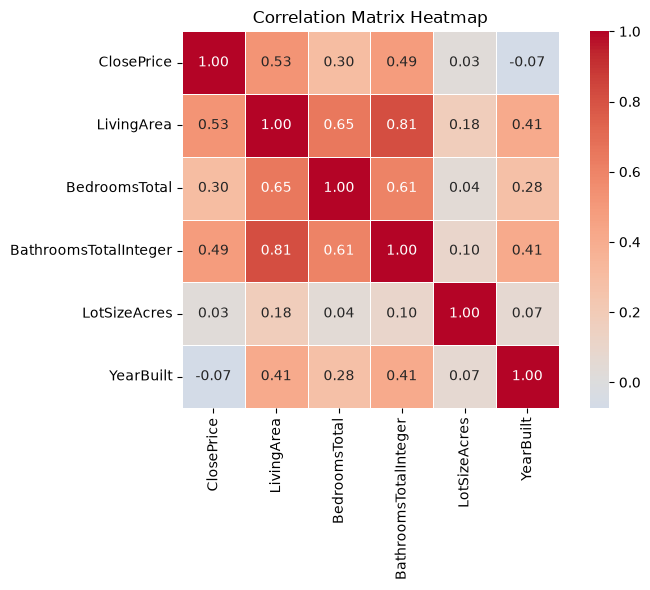

In [46]:
num_cols = ['ClosePrice', 'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeAcres', 'YearBuilt']
corr_df = df[num_cols].copy()

for col in num_cols:
    low, high = corr_df[col].quantile([0.01, 0.99])
    corr_df = corr_df[corr_df[col].between(low, high)]

print(f'Rows used for correlation: {len(corr_df):,}')

# ranking predictors by their Spearman correlation with ClosePrice
ranking = ( 
    corr_df.corr(method='spearman')['ClosePrice']
    .drop('ClosePrice')
    .sort_values(ascending=False)
)
print(f'Spearman correlation with ClosePrice: \n{ranking}')

#Heatmap of correlation matrix across the variable pairings via pearson method

corr = corr_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()


### Analysis

In this section it is evident that despite the methods of checking for correlation, it's possible to quantify the earlier findings. In both methods, LivingArea and BathroomsTotalInteger, have the strongest predictability for ClosePrice. On the other end, LotSizeAcres and YearBuilt are essentially the weakest predictors for ClosePrice.

# Final Summary

This EDA explored six months of CRMLS single-family residential sales (Dec 2025 – May 2026) to characterize the target variable (ClosePrice) and other variables/predictors. 

## Exploration of Distributions
- **ClosePrice** is strongly right-skewed (mean $1.34M vs. median $890K), driven by a small number of extreme high-value outlier sales. A log transform produces a near-symmetric distribution and is recommended for modeling.
- **LivingArea** is moderately right-skewed and also log-normalizes well.
- **BedroomsTotal** and **BathroomsTotalInteger** are small discrete counts with only mild skew; the bulk of homes have 2–4 of each.
- **LotSizeAcres** is the most extremely skewed variable, and notably a log transform doesn't see, to resolve its skew as the extreme values are driven by identifiable data errors rather than natural variation. 

## Next Steps
- Address implausible values and the LotSizeAcres unit errors (correct or remove).
- Decide a deduplication strategy for conflicting ListingKey rows.
- Handle missing values (impute or drop) and recode boolean fields where NaN encodes "False."

*Note: see Week_2_Documentation for the outline of the process taken to perform this eda*